In [1]:
import pandas_datareader.data as web
import datetime as dt
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import norm
from scipy.optimize import brentq
from mpl_toolkits.mplot3d import Axes3D

In [11]:
start = dt.datetime(2020, 1, 1)
end = dt.datetime.now()

stocks = ['AAPL', 'MSFT', 'GOOGL', 'TSLA', 'SBUX']

In [15]:
data = {}

for stock in stocks:
    df = web.DataReader(stock, 'stooq', start, end)
    df = df.sort_index()      # IMPORTANT for time series
    df['Ticker'] = stock
    data[stock] = df

In [17]:
all_df = pd.concat(data.values())
all_df.reset_index(inplace=True)

In [19]:
# -----------------------------
# 2. Build price matrix (Close prices)
# -----------------------------

# Keep only Date, Ticker, and Close
price_df = all_df[['Date', 'Ticker', 'Close']].copy()

# Pivot to wide format: rows = dates, columns = tickers
price_wide = price_df.pivot(index='Date', columns='Ticker', values='Close')

# Sort by date and drop any rows with missing values
price_wide = price_wide.sort_index().dropna()

price_wide.head()


Ticker,AAPL,GOOGL,MSFT,SBUX,TSLA
Date,,,,,
2020-01-02,72.4683,68.1868,153.613,84.1231,28.6840
2020-01-03,71.7661,67.8302,151.726,83.6324,29.5340
2020-01-06,72.3337,69.6381,152.118,82.9725,30.1027
2020-01-07,71.9970,69.5035,150.710,82.7193,31.2707
2020-01-08,73.1541,69.9983,153.142,83.6795,32.8093


In [21]:
# -----------------------------
# 3. Compute daily log returns
# -----------------------------

# Log returns: r_t = ln(P_t / P_{t-1})
returns = np.log(price_wide / price_wide.shift(1))

# Drop the first row (NaN)
returns = returns.dropna()

returns.head()


Ticker,AAPL,GOOGL,MSFT,SBUX,TSLA
Date,,,,,
2020-01-03,-0.009737,-0.005243,-0.012360,-0.005850,0.029203
2020-01-06,0.007878,0.026304,0.002580,-0.007922,0.019073
2020-01-07,-0.004666,-0.001935,-0.009299,-0.003056,0.038067
2020-01-08,0.015944,0.007094,0.016008,0.011541,0.048030
2020-01-09,0.021052,0.010441,0.012240,0.018402,-0.022189


In [23]:
# -----------------------------
# 4. Summary statistics
# -----------------------------

summary_stats = returns.describe().T
summary_stats['skew'] = returns.skew()
summary_stats['kurtosis'] = returns.kurtosis()

summary_stats


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
Ticker,,,,,,,,,,
AAPL,1558.0,0.000806,0.019881,-0.137692,-0.008284,0.001105,0.011014,0.142623,0.027854,6.429398
GOOGL,1558.0,0.000974,0.020272,-0.123685,-0.009484,0.001654,0.011536,0.097345,-0.161633,3.735479
MSFT,1558.0,0.000613,0.018737,-0.159549,-0.008012,0.000910,0.010342,0.132972,-0.264459,7.962954
SBUX,1558.0,0.000095,0.021177,-0.176756,-0.009611,-0.000092,0.009762,0.219111,0.245039,17.229190
TSLA,1558.0,0.001690,0.041311,-0.236518,-0.020324,0.001618,0.022635,0.204491,-0.081167,3.427672


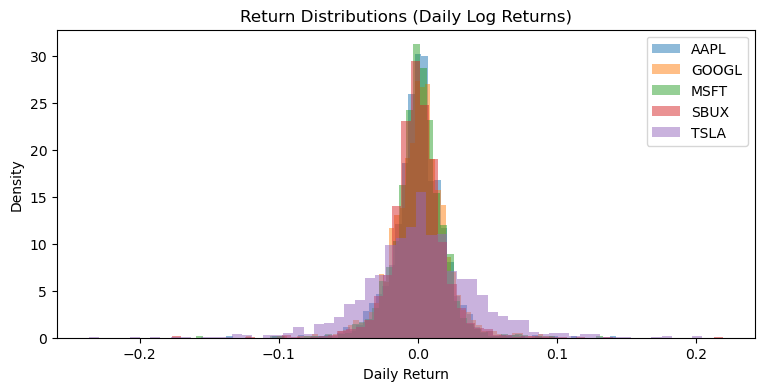

In [29]:
# -----------------------------
# 4b. Plot return distributions
# -----------------------------

plt.figure(figsize=(9, 4))

for ticker in returns.columns:
    plt.hist(returns[ticker], bins=60, alpha=0.5, label=ticker, density=True)

plt.title("Return Distributions (Daily Log Returns)")
plt.xlabel("Daily Return")
plt.ylabel("Density")
plt.legend()
plt.show()


In [31]:
# -----------------------------
# 5. Correlation matrix
# -----------------------------

corr_matrix = returns.corr()
corr_matrix


Ticker,AAPL,GOOGL,MSFT,SBUX,TSLA
Ticker,,,,,
AAPL,1.000000,0.618663,0.688145,0.494692,0.491139
GOOGL,0.618663,1.000000,0.679453,0.410190,0.423976
MSFT,0.688145,0.679453,1.000000,0.459025,0.450593
SBUX,0.494692,0.410190,0.459025,1.000000,0.328480
TSLA,0.491139,0.423976,0.450593,0.328480,1.000000


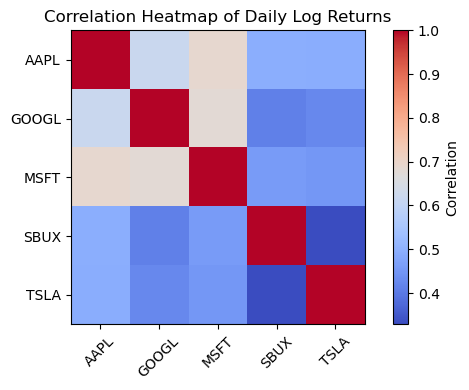

In [35]:
# -----------------------------
# 5b. Correlation heatmap
# -----------------------------

plt.figure(figsize=(6, 4))
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label='Correlation')

plt.xticks(range(len(corr_matrix)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix)), corr_matrix.columns)

plt.title("Correlation Heatmap of Daily Log Returns")
plt.tight_layout()
plt.show()


In [37]:
# -----------------------------
# 6. Covariance matrix & annualized volatility
# -----------------------------

# Daily covariance matrix
cov_matrix = returns.cov()

# Annualized covariance matrix
cov_matrix_annual = cov_matrix * 252

# Annualized volatility (standard deviation)
annual_vol = returns.std() * np.sqrt(252)

cov_matrix_annual, annual_vol


(Ticker      AAPL     GOOGL      MSFT      SBUX      TSLA
 Ticker                                                  
 AAPL    0.099602  0.062833  0.064596  0.052485  0.101650
 GOOGL   0.062833  0.103563  0.065035  0.044376  0.089477
 MSFT    0.064596  0.065035  0.088466  0.045898  0.087891
 SBUX    0.052485  0.044376  0.045898  0.113013  0.072418
 TSLA    0.101650  0.089477  0.087891  0.072418  0.430073,
 Ticker
 AAPL     0.315597
 GOOGL    0.321811
 MSFT     0.297433
 SBUX     0.336173
 TSLA     0.655799
 dtype: float64)

In [39]:
# -----------------------------
# 7. Equal-weight portfolio
# -----------------------------

# Number of assets
n_assets = returns.shape[1]

# Equal weights
weights_eq = np.ones(n_assets) / n_assets

# Daily portfolio returns
portfolio_returns_eq = returns.dot(weights_eq)

# Cumulative performance
cumulative_eq = (1 + portfolio_returns_eq).cumprod()

# Annualized return
annual_return_eq = portfolio_returns_eq.mean() * 252

# Annualized volatility
annual_vol_eq = portfolio_returns_eq.std() * np.sqrt(252)

# Sharpe ratio (risk-free rate assumed 0 for simplicity)
sharpe_eq = annual_return_eq / annual_vol_eq

annual_return_eq, annual_vol_eq, sharpe_eq


(0.21057734851340545, 0.2971890314213055, 0.7085636623475638)

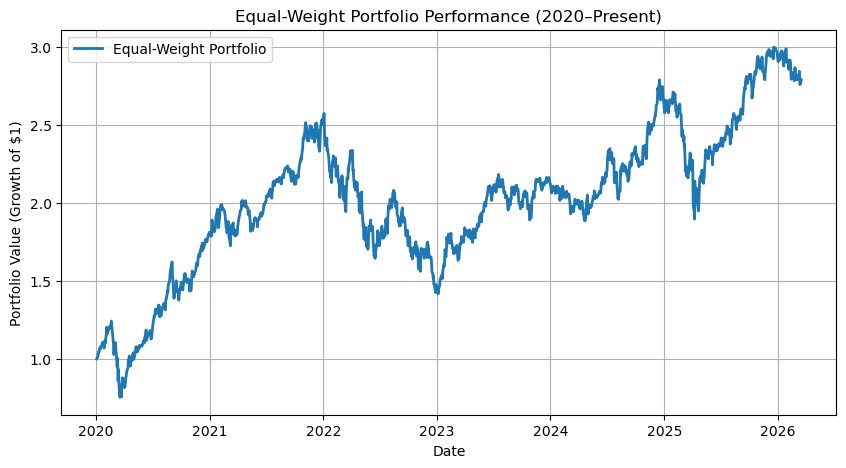

In [41]:
# -----------------------------
# 7b. Plot cumulative performance
# -----------------------------

plt.figure(figsize=(10, 5))
plt.plot(cumulative_eq, label='Equal-Weight Portfolio', linewidth=2)

plt.title("Equal-Weight Portfolio Performance (2020–Present)")
plt.xlabel("Date")
plt.ylabel("Portfolio Value (Growth of $1)")
plt.grid(True)
plt.legend()
plt.show()


In [43]:
# -----------------------------
# 8. Minimum-Variance Portfolio
# -----------------------------

from scipy.optimize import minimize

# Number of assets
n = returns.shape[1]

# Objective: portfolio variance
def portfolio_variance(weights, cov_matrix):
    return weights.T @ cov_matrix @ weights

# Constraint: weights sum to 1
constraints = ({
    'type': 'eq',
    'fun': lambda w: np.sum(w) - 1
})

# Bounds: no short-selling (0 ≤ w ≤ 1)
bounds = tuple((0, 1) for _ in range(n))

# Initial guess: equal weights
w0 = np.ones(n) / n

# Solve optimization
result = minimize(
    portfolio_variance,
    w0,
    args=(cov_matrix_annual,),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

weights_mvp = result.x
weights_mvp


array([1.71458134e-01, 2.13982562e-01, 3.16245493e-01, 2.98313811e-01,
       9.97465999e-18])

In [45]:
# -----------------------------
# 8b. MVP performance metrics
# -----------------------------

# Daily returns of MVP
portfolio_returns_mvp = returns.dot(weights_mvp)

# Cumulative performance
cumulative_mvp = (1 + portfolio_returns_mvp).cumprod()

# Annualized return
annual_return_mvp = portfolio_returns_mvp.mean() * 252

# Annualized volatility
annual_vol_mvp = portfolio_returns_mvp.std() * np.sqrt(252)

# Sharpe ratio
sharpe_mvp = annual_return_mvp / annual_vol_mvp

annual_return_mvp, annual_vol_mvp, sharpe_mvp


(0.14335427637946857, 0.25823810962282046, 0.5551244027802485)

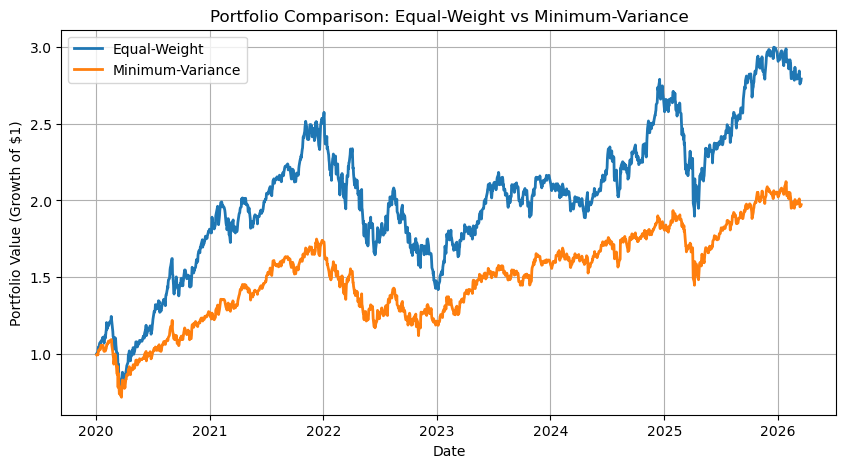

In [47]:
# -----------------------------
# 8c. Plot MVP vs Equal-Weight
# -----------------------------

plt.figure(figsize=(10, 5))
plt.plot(cumulative_eq, label='Equal-Weight', linewidth=2)
plt.plot(cumulative_mvp, label='Minimum-Variance', linewidth=2)

plt.title("Portfolio Comparison: Equal-Weight vs Minimum-Variance")
plt.xlabel("Date")
plt.ylabel("Portfolio Value (Growth of $1)")
plt.grid(True)
plt.legend()
plt.show()


In [49]:
# -----------------------------
# 9. Maximum Sharpe Ratio Portfolio
# -----------------------------

# Expected returns (annualized)
mu = returns.mean() * 252

# Objective: negative Sharpe ratio
def neg_sharpe_ratio(weights, mu, cov_matrix):
    ret = np.dot(weights, mu)
    vol = np.sqrt(weights.T @ cov_matrix @ weights)
    return -ret / vol

# Constraints: weights sum to 1
constraints = ({
    'type': 'eq',
    'fun': lambda w: np.sum(w) - 1
})

# Bounds: no short-selling
bounds = tuple((0, 1) for _ in range(n))

# Initial guess
w0 = np.ones(n) / n

# Solve optimization
result = minimize(
    neg_sharpe_ratio,
    w0,
    args=(mu, cov_matrix_annual),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

weights_max_sharpe = result.x
weights_max_sharpe


array([1.76436490e-01, 6.16305518e-01, 0.00000000e+00, 4.77048956e-17,
       2.07257992e-01])

In [51]:
# -----------------------------
# 9b. Max Sharpe performance metrics
# -----------------------------

portfolio_returns_ms = returns.dot(weights_max_sharpe)

cumulative_ms = (1 + portfolio_returns_ms).cumprod()

annual_return_ms = portfolio_returns_ms.mean() * 252
annual_vol_ms = portfolio_returns_ms.std() * np.sqrt(252)
sharpe_ms = annual_return_ms / annual_vol_ms

annual_return_ms, annual_vol_ms, sharpe_ms


(0.2753442480126917, 0.3238346149687402, 0.8502619401550717)

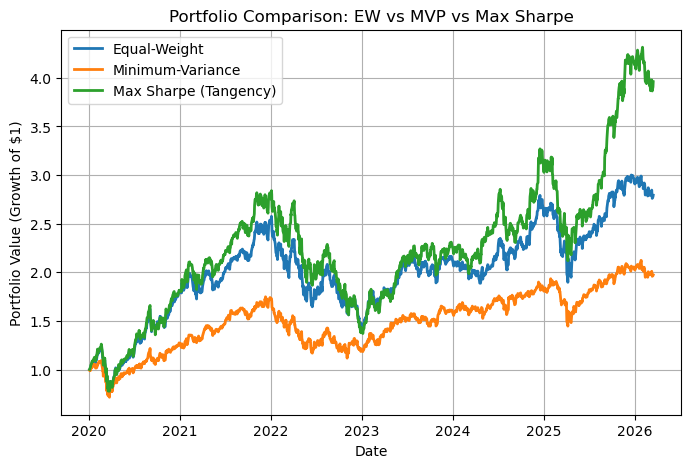

In [55]:
# -----------------------------
# 9c. Compare all portfolios
# -----------------------------

plt.figure(figsize=(8, 5))
plt.plot(cumulative_eq, label='Equal-Weight', linewidth=2)
plt.plot(cumulative_mvp, label='Minimum-Variance', linewidth=2)
plt.plot(cumulative_ms, label='Max Sharpe (Tangency)', linewidth=2)

plt.title("Portfolio Comparison: EW vs MVP vs Max Sharpe")
plt.xlabel("Date")
plt.ylabel("Portfolio Value (Growth of $1)")
plt.grid(True)
plt.legend()
plt.show()


In [57]:
# -----------------------------
# 10. Efficient Frontier
# -----------------------------

n_portfolios = 5000
results = np.zeros((n_portfolios, 3))  # columns: return, vol, sharpe
weights_record = []

for i in range(n_portfolios):
    # Random weights that sum to 1
    w = np.random.random(n)
    w /= np.sum(w)
    
    weights_record.append(w)
    
    # Portfolio return & volatility
    ret = np.dot(w, mu)
    vol = np.sqrt(w.T @ cov_matrix_annual @ w)
    sharpe = ret / vol
    
    results[i] = [ret, vol, sharpe]

# Convert to DataFrame
ef_df = pd.DataFrame(results, columns=['Return', 'Volatility', 'Sharpe'])


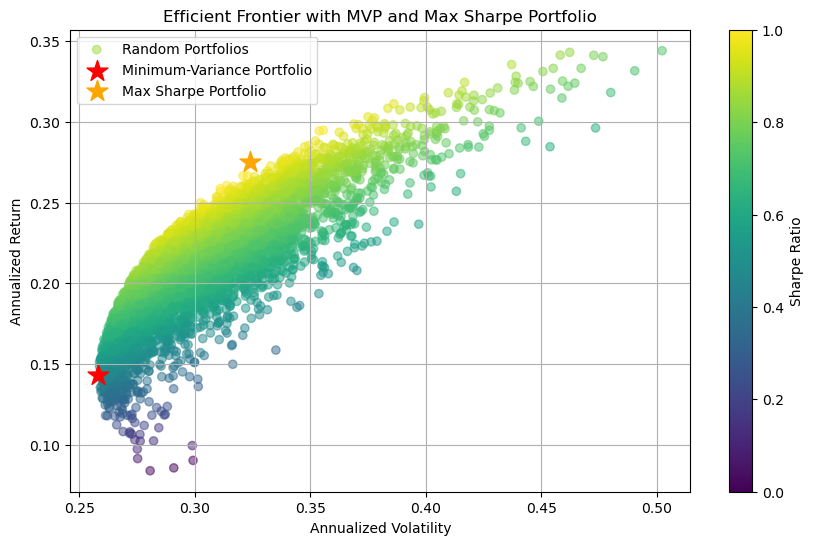

In [59]:
# -----------------------------
# 10b. Plot Efficient Frontier
# -----------------------------

plt.figure(figsize=(10, 6))

# Scatter all random portfolios
plt.scatter(
    ef_df['Volatility'], 
    ef_df['Return'], 
    c=ef_df['Sharpe'], 
    cmap='viridis', 
    alpha=0.5,
    label='Random Portfolios'
)

# Plot MVP
plt.scatter(
    annual_vol_mvp, 
    annual_return_mvp, 
    color='red', 
    marker='*', 
    s=250, 
    label='Minimum-Variance Portfolio'
)

# Plot Max Sharpe
plt.scatter(
    annual_vol_ms, 
    annual_return_ms, 
    color='orange', 
    marker='*', 
    s=250, 
    label='Max Sharpe Portfolio'
)

plt.title("Efficient Frontier with MVP and Max Sharpe Portfolio")
plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Return")
plt.colorbar(label='Sharpe Ratio')
plt.legend()
plt.grid(True)
plt.show()


In [61]:
# -----------------------------
# 11. Risk Decomposition
# -----------------------------

def risk_decomposition(weights, cov_matrix):
    # Portfolio volatility
    portfolio_vol = np.sqrt(weights.T @ cov_matrix @ weights)
    
    # Marginal contribution to risk
    mcr = (cov_matrix @ weights) / portfolio_vol
    
    # Total contribution to risk
    tcr = weights * mcr
    
    # Percentage contribution
    pcr = tcr / portfolio_vol
    
    return portfolio_vol, mcr, tcr, pcr


In [63]:
# -----------------------------
# 11b. Apply risk decomposition
# -----------------------------

vol_mvp, mcr_mvp, tcr_mvp, pcr_mvp = risk_decomposition(weights_mvp, cov_matrix_annual)
vol_ms, mcr_ms, tcr_ms, pcr_ms = risk_decomposition(weights_max_sharpe, cov_matrix_annual)

risk_decomp_df = pd.DataFrame({
    'Weight_MVP': weights_mvp,
    'PCR_MVP': pcr_mvp,
    'Weight_MaxSharpe': weights_max_sharpe,
    'PCR_MaxSharpe': pcr_ms
}, index=returns.columns)

risk_decomp_df


,Weight_MVP,PCR_MVP,Weight_MaxSharpe,PCR_MaxSharpe
Ticker,,,,
AAPL,1.714581e-01,1.712542e-01,1.764365e-01,1.301636e-01
GOOGL,2.139826e-01,2.141498e-01,6.163055e-01,5.492397e-01
MSFT,3.162455e-01,3.161220e-01,0.000000e+00,0.000000e+00
SBUX,2.983138e-01,2.984740e-01,4.770490e-17,2.348133e-17
TSLA,9.974660e-18,1.285946e-17,2.072580e-01,3.205966e-01


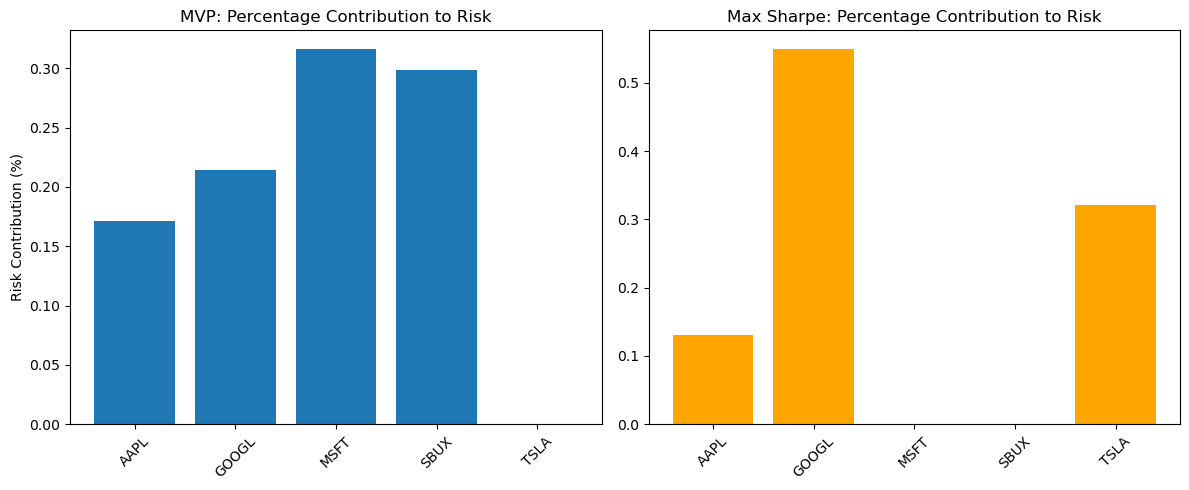

In [65]:
# -----------------------------
# 11c. Plot risk contributions
# -----------------------------

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(returns.columns, pcr_mvp)
plt.title("MVP: Percentage Contribution to Risk")
plt.ylabel("Risk Contribution (%)")
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
plt.bar(returns.columns, pcr_ms, color='orange')
plt.title("Max Sharpe: Percentage Contribution to Risk")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [67]:
# -----------------------------
# 12. PCA Factor Analysis
# -----------------------------

from sklearn.decomposition import PCA

# Standardize returns (important for PCA)
returns_std = (returns - returns.mean()) / returns.std()

# Fit PCA
pca = PCA()
pca.fit(returns_std)

# Variance explained
variance_explained = pca.explained_variance_ratio_

variance_explained


array([0.60956299, 0.13440297, 0.12444345, 0.07311349, 0.0584771 ])

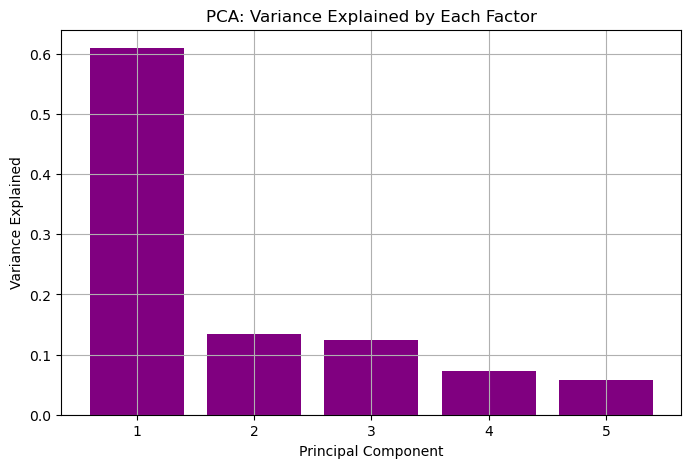

In [69]:
# -----------------------------
# 12b. Plot variance explained
# -----------------------------

plt.figure(figsize=(8, 5))
plt.bar(range(1, len(variance_explained)+1), variance_explained, color='purple')
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained")
plt.title("PCA: Variance Explained by Each Factor")
plt.grid(True)
plt.show()


In [71]:
# -----------------------------
# 12c. PCA Factor Loadings
# -----------------------------

loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(len(returns.columns))],
    index=returns.columns
)

loadings


,PC1,PC2,PC3,PC4,PC5
Ticker,,,,,
AAPL,-0.492141,0.007001,-0.113575,0.701055,0.503359
GOOGL,-0.468648,-0.046305,-0.459376,-0.661478,0.360065
MSFT,-0.491833,0.004261,-0.344611,0.161176,-0.783166
SBUX,-0.384762,0.727217,0.541807,-0.169675,-0.027737
TSLA,-0.385000,-0.684795,0.603128,-0.127287,-0.053529


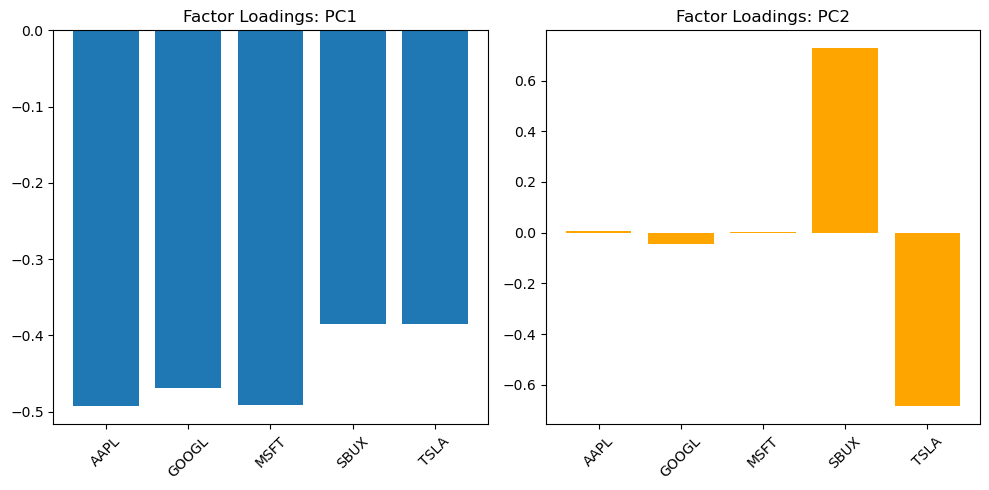

In [73]:
# -----------------------------
# 12d. Plot factor loadings
# -----------------------------

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.bar(returns.columns, loadings['PC1'])
plt.title("Factor Loadings: PC1")
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
plt.bar(returns.columns, loadings['PC2'], color='orange')
plt.title("Factor Loadings: PC2")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [75]:
# -----------------------------
# 13. Rolling volatility (per asset)
# -----------------------------

rolling_vol = returns.rolling(window=60).std() * np.sqrt(252)

rolling_vol.tail()


Ticker,AAPL,GOOGL,MSFT,SBUX,TSLA
Date,,,,,
2026-03-11,0.233582,0.217022,0.323327,0.275763,0.362596
2026-03-12,0.236589,0.218763,0.323109,0.277433,0.363023
2026-03-13,0.238818,0.218813,0.324046,0.278683,0.354762
2026-03-16,0.240048,0.219726,0.325084,0.280327,0.349187
2026-03-17,0.239757,0.211805,0.325064,0.280502,0.338014


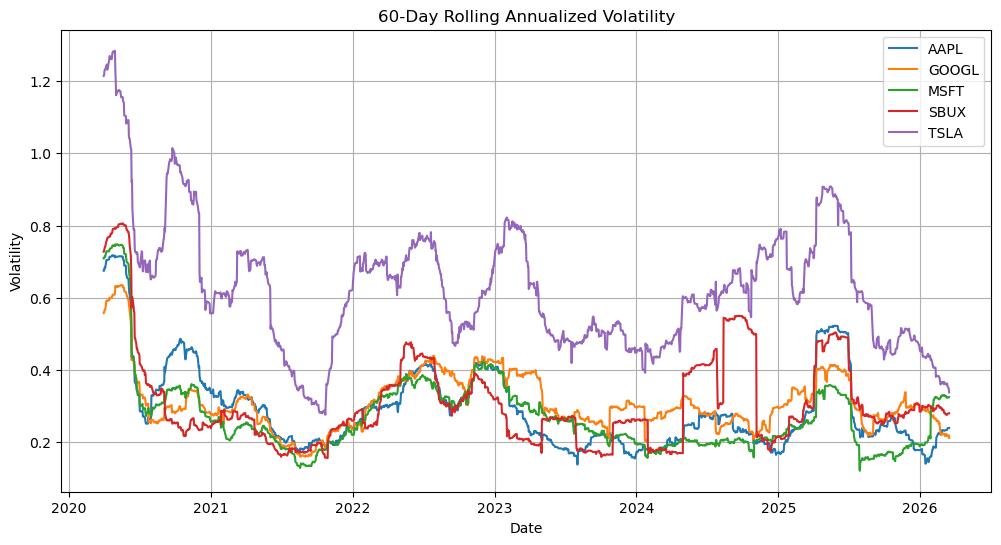

In [77]:
# -----------------------------
# 13b. Plot rolling volatility
# -----------------------------

plt.figure(figsize=(12, 6))

for ticker in returns.columns:
    plt.plot(rolling_vol[ticker], label=ticker)

plt.title("60-Day Rolling Annualized Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.grid(True)
plt.show()


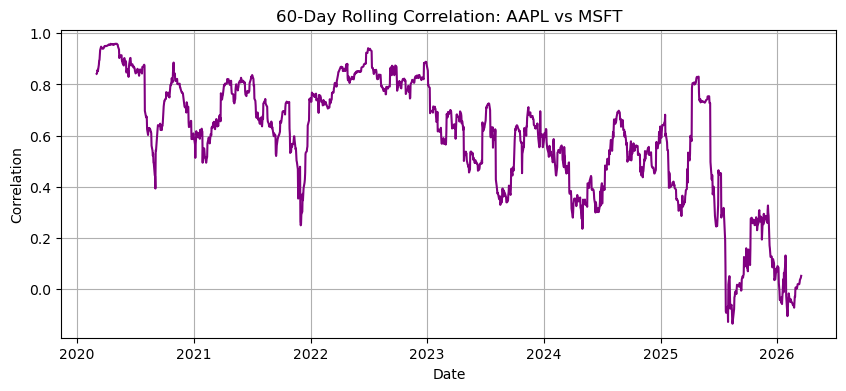

In [107]:
# -----------------------------
# 13c. Rolling correlation (AAPL vs MSFT)
# -----------------------------

rolling_corr = returns['AAPL'].rolling(40).corr(returns['MSFT'])

plt.figure(figsize=(10, 4))
plt.plot(rolling_corr, color='purple')
plt.title("60-Day Rolling Correlation: AAPL vs MSFT")
plt.xlabel("Date")
plt.ylabel("Correlation")
plt.grid(True)
plt.show()


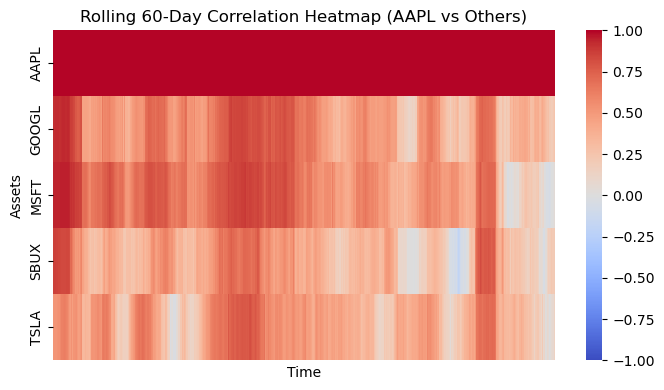

In [159]:
import seaborn as sns

# Compute rolling correlation matrices
window = 60
tickers = returns.columns

# Store results in a list
rolling_corr_matrices = []

for i in range(window, len(returns)):
    corr_matrix = returns.iloc[i-window:i].corr()
    rolling_corr_matrices.append(corr_matrix.values)

# Convert to 3D array: (time, assets, assets)
rolling_corr_matrices = np.array(rolling_corr_matrices)

# Choose a pair to visualize as heatmap over time
# Example: AAPL vs all others
asset_index = tickers.get_loc("AAPL")

corr_over_time = rolling_corr_matrices[:, asset_index, :]

plt.figure(figsize=(7, 4))
sns.heatmap(
    corr_over_time.T,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    xticklabels=False,
    yticklabels=tickers
)

plt.title("Rolling 60-Day Correlation Heatmap (AAPL vs Others)")
plt.xlabel("Time")
plt.ylabel("Assets")
plt.tight_layout()
plt.show()


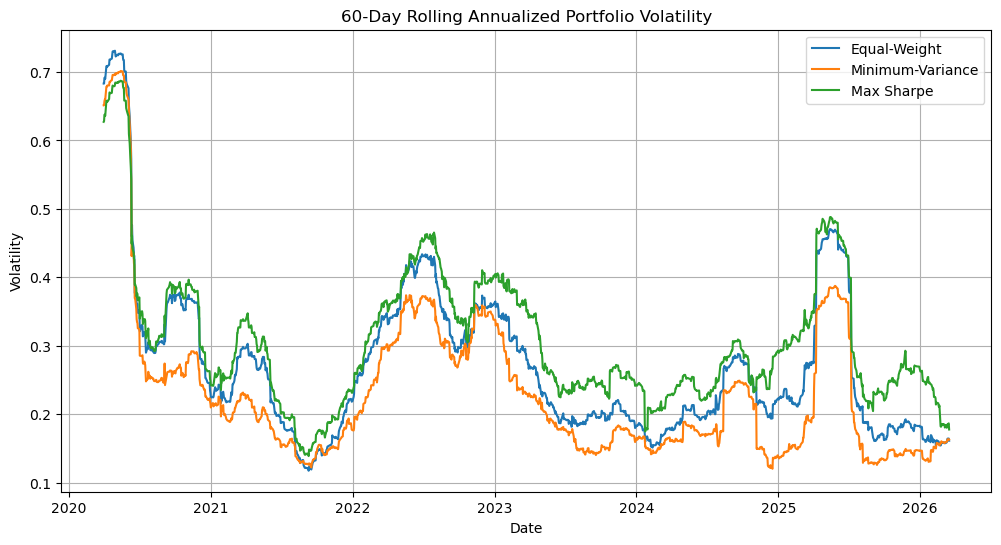

In [81]:
# -----------------------------
# 13d. Rolling portfolio volatility
# -----------------------------

rolling_vol_eq = portfolio_returns_eq.rolling(60).std() * np.sqrt(252)
rolling_vol_mvp = portfolio_returns_mvp.rolling(60).std() * np.sqrt(252)
rolling_vol_ms = portfolio_returns_ms.rolling(60).std() * np.sqrt(252)

plt.figure(figsize=(12, 6))
plt.plot(rolling_vol_eq, label='Equal-Weight')
plt.plot(rolling_vol_mvp, label='Minimum-Variance')
plt.plot(rolling_vol_ms, label='Max Sharpe')

plt.title("60-Day Rolling Annualized Portfolio Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.grid(True)
plt.show()


In [83]:
# -----------------------------
# 14. Max Drawdown function
# -----------------------------

def max_drawdown(cumulative_returns):
    running_max = cumulative_returns.cummax()
    drawdown = (cumulative_returns - running_max) / running_max
    return drawdown.min()


In [85]:
# -----------------------------
# 14b. Compute metrics for all portfolios
# -----------------------------

summary = pd.DataFrame({
    'Annual Return': [
        annual_return_eq,
        annual_return_mvp,
        annual_return_ms
    ],
    'Annual Volatility': [
        annual_vol_eq,
        annual_vol_mvp,
        annual_vol_ms
    ],
    'Sharpe Ratio': [
        sharpe_eq,
        sharpe_mvp,
        sharpe_ms
    ],
    'Max Drawdown': [
        max_drawdown(cumulative_eq),
        max_drawdown(cumulative_mvp),
        max_drawdown(cumulative_ms)
    ]
}, index=['Equal-Weight', 'Minimum-Variance', 'Max Sharpe'])

summary


,Annual Return,Annual Volatility,Sharpe Ratio,Max Drawdown
Equal-Weight,0.210577,0.297189,0.708564,-0.449667
Minimum-Variance,0.143354,0.258238,0.555124,-0.360861
Max Sharpe,0.275344,0.323835,0.850262,-0.517472


In [87]:
summary.style.format({
    'Annual Return': '{:.2%}',
    'Annual Volatility': '{:.2%}',
    'Sharpe Ratio': '{:.2f}',
    'Max Drawdown': '{:.2%}'
})


,Annual Return,Annual Volatility,Sharpe Ratio,Max Drawdown
Equal-Weight,21.06%,29.72%,0.71,-44.97%
Minimum-Variance,14.34%,25.82%,0.56,-36.09%
Max Sharpe,27.53%,32.38%,0.85,-51.75%


In [93]:
# -----------------------------
# 15. Monte Carlo simulation (final fixed version)
# -----------------------------

n_sims = 5000
horizon_days = 252

# Cholesky decomposition for correlated shocks
chol = np.linalg.cholesky(cov_matrix_annual / 252)

def simulate_portfolio_paths(weights, n_sims, horizon_days, mu, cov_matrix_annual, chol):
    n_assets = len(weights)
    dt = 1 / 252

    # Convert to numpy arrays (CRITICAL FIX)
    mu = np.array(mu)
    vol_diag = np.diag(cov_matrix_annual)
    drift = (mu - 0.5 * vol_diag) * dt   # shape (5,)
    drift = drift.reshape(1, -1)         # shape (1,5) for broadcasting

    terminal_values = np.zeros(n_sims)

    for i in range(n_sims):
        # Simulate correlated shocks
        z = np.random.normal(size=(horizon_days, n_assets))
        shocks = z @ chol.T              # shape (252,5)

        # Daily log returns
        daily_log_ret = drift + shocks   # shape (252,5)

        # Convert to arithmetic returns
        daily_port_ret = np.exp(daily_log_ret) - 1

        # Portfolio daily returns
        portfolio_daily = daily_port_ret @ weights

        # Terminal value starting from 1
        terminal_values[i] = np.prod(1 + portfolio_daily)

    return terminal_values


# Run simulations
terminal_eq = simulate_portfolio_paths(weights_eq, n_sims, horizon_days, mu, cov_matrix_annual, chol)
terminal_mvp = simulate_portfolio_paths(weights_mvp, n_sims, horizon_days, mu, cov_matrix_annual, chol)
terminal_ms = simulate_portfolio_paths(weights_max_sharpe, n_sims, horizon_days, mu, cov_matrix_annual, chol)


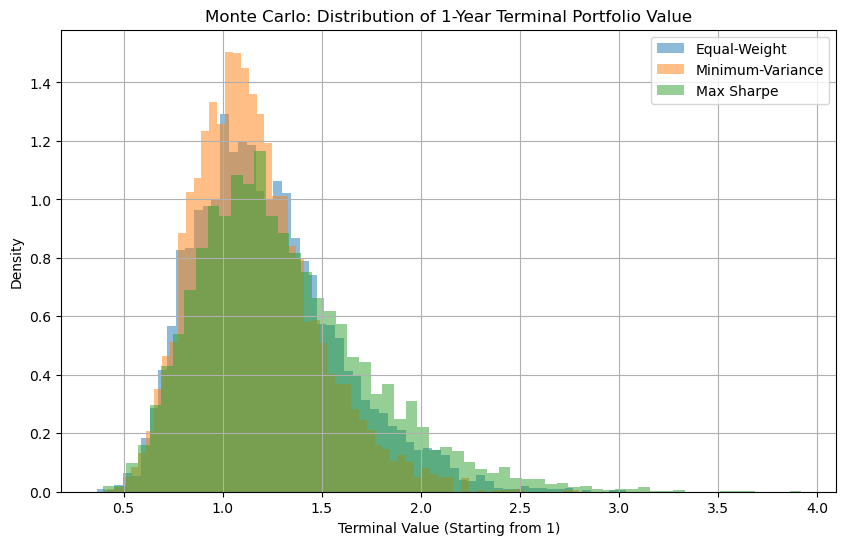

In [95]:
# -----------------------------
# 15b. Plot terminal value distributions
# -----------------------------

plt.figure(figsize=(10, 6))

plt.hist(terminal_eq, bins=60, alpha=0.5, label='Equal-Weight', density=True)
plt.hist(terminal_mvp, bins=60, alpha=0.5, label='Minimum-Variance', density=True)
plt.hist(terminal_ms, bins=60, alpha=0.5, label='Max Sharpe', density=True)

plt.title("Monte Carlo: Distribution of 1-Year Terminal Portfolio Value")
plt.xlabel("Terminal Value (Starting from 1)")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()


In [97]:
# -----------------------------
# 15c. Monte Carlo summary stats
# -----------------------------

mc_summary = pd.DataFrame({
    'Mean Terminal Value': [
        terminal_eq.mean(),
        terminal_mvp.mean(),
        terminal_ms.mean()
    ],
    '5% VaR (Terminal)': [
        np.percentile(terminal_eq, 5),
        np.percentile(terminal_mvp, 5),
        np.percentile(terminal_ms, 5)
    ],
    '1% VaR (Terminal)': [
        np.percentile(terminal_eq, 1),
        np.percentile(terminal_mvp, 1),
        np.percentile(terminal_ms, 1)
    ]
}, index=['Equal-Weight', 'Minimum-Variance', 'Max Sharpe'])

mc_summary


,Mean Terminal Value,5% VaR (Terminal),1% VaR (Terminal)
Equal-Weight,1.225674,0.729115,0.606269
Minimum-Variance,1.155776,0.729932,0.607373
Max Sharpe,1.308018,0.724773,0.587795


In [111]:
import os

# Create folders if they don't exist
os.makedirs("images", exist_ok=True)
os.makedirs("data", exist_ok=True)


In [113]:
plt.savefig("images/NAME_OF_FIGURE.png", dpi=300, bbox_inches='tight')


<Figure size 640x480 with 0 Axes>

In [115]:
plt.savefig("images/efficient_frontier.png", dpi=300, bbox_inches='tight')


<Figure size 640x480 with 0 Axes>

In [117]:
plt.savefig("images/portfolio_comparison.png", dpi=300, bbox_inches='tight')


<Figure size 640x480 with 0 Axes>

In [119]:
plt.savefig("images/portfolio_comparison.png", dpi=300, bbox_inches='tight')


<Figure size 640x480 with 0 Axes>

In [121]:
plt.savefig("images/rolling_volatility.png", dpi=300, bbox_inches='tight')


<Figure size 640x480 with 0 Axes>

In [123]:
plt.savefig("images/rolling_volatility.png", dpi=300, bbox_inches='tight')


<Figure size 640x480 with 0 Axes>

In [125]:
plt.savefig("images/rolling_correlation.png", dpi=300, bbox_inches='tight')


<Figure size 640x480 with 0 Axes>

In [127]:
plt.savefig("images/risk_contribution_mvp.png", dpi=300, bbox_inches='tight')


<Figure size 640x480 with 0 Axes>

In [129]:
plt.savefig("images/risk_contribution_maxsharpe.png", dpi=300, bbox_inches='tight')


<Figure size 640x480 with 0 Axes>

In [131]:
plt.savefig("images/pca_variance_explained.png", dpi=300, bbox_inches='tight')


<Figure size 640x480 with 0 Axes>

In [133]:
plt.savefig("images/pca_loadings.png", dpi=300, bbox_inches='tight')


<Figure size 640x480 with 0 Axes>

In [135]:
plt.savefig("images/monte_carlo_terminal_values.png", dpi=300, bbox_inches='tight')


<Figure size 640x480 with 0 Axes>

In [141]:
price_df.to_csv("data/prices.csv")


In [143]:
returns.to_csv("data/returns.csv")


In [145]:
import pandas as pd

weights_df = pd.DataFrame({
    "Equal_Weight": weights_eq,
    "MVP": weights_mvp,
    "Max_Sharpe": weights_max_sharpe
}, index=returns.columns)

weights_df.to_csv("data/portfolio_weights.csv")


In [147]:
summary.to_csv("data/performance_summary.csv")


In [149]:
mc_df = pd.DataFrame({
    "terminal_eq": terminal_eq,
    "terminal_mvp": terminal_mvp,
    "terminal_ms": terminal_ms
})

mc_df.to_csv("data/monte_carlo_results.csv", index=False)


In [151]:
pd.DataFrame(cov_matrix_annual, index=returns.columns, columns=returns.columns).to_csv("data/covariance_matrix.csv")
pd.Series(mu, index=returns.columns).to_csv("data/expected_returns.csv")
